# Joint Multi-System Fit (GWT)

Cross-system comparison (notebook 10) revealed that independent per-system fits produce degenerate observation-layer parameters at extreme systems (ELIZA: $a = 0.29$), making the model unable to differentiate Human from ELIZA. All four systems clustered at the prior mean.

This notebook fits GWT **jointly** across {Human, Chicken, LLMs, ELIZA} with:
- **Shared** observation layer $(a, \kappa, b_e)$ — calibrated primarily from LLM data (most spread)
- **Shared** tree parameters $(\beta^{\rm pres}, \beta^{\rm abs})$ at every node
- **Fixed** reference credences: Human $C = 0.99$, ELIZA $C = 0.01$
- **Diffuse** Beta(1, 5) prior on Chicken and LLMs (target systems)

Expected outcome: Human >> Chicken > LLMs > ELIZA with meaningful separation.

In [ ]:
import os, sys, warnings, time

os.environ["PYTENSOR_FLAGS"] = f"compiledir=/tmp/pytensor_cache_nb11_{os.getpid()}"
sys.path.insert(0, "..")
os.chdir(os.path.join(os.path.dirname(os.path.abspath("."))))
warnings.filterwarnings("ignore", message="Loop fusion failed")

import numpy as np
import arviz as az
import matplotlib.pyplot as plt

from dcm_model import (
    ModelConfig,
    load_data,
    fit_stance_multisystem,
    fit_stance,
)

plt.rcParams.update(
    {"figure.dpi": 120, "font.size": 10, "figure.constrained_layout.use": True}
)

In [ ]:
STANCE = "Global Workspace Theory"
SYSTEM_CONFIGS = [
    ("Human", 0.99),  # reference: near-certain conscious
    ("Chicken", None),  # target: diffuse prior
    ("2024 Leading Chat LLMs", None),  # target: diffuse prior
    ("ELIZA", 0.01),  # reference: near-certain not conscious
]

cfg = ModelConfig(
    NUM_SAMPLES=2000,
    NUM_TUNE=1500,
    NUM_CHAINS=4,
    TARGET_ACCEPT=0.95,
)

all_data = load_data(cfg)
stance_data = next(s for s in all_data if s["name"] == STANCE)

print("Fitting joint multi-system model...")
print(f"  Stance: {STANCE}")
print(f"  Systems: {[s for s, _ in SYSTEM_CONFIGS]}")
print(f"  References: {[(s, c) for s, c in SYSTEM_CONFIGS if c is not None]}")
print(f"  Targets: {[s for s, c in SYSTEM_CONFIGS if c is None]}")
print()

t0 = time.time()
idata, builder, processor = fit_stance_multisystem(stance_data, cfg, SYSTEM_CONFIGS)
elapsed = time.time() - t0
print(f"\nTotal elapsed: {elapsed:.0f}s")

Fitting joint multi-system model...
  Stance: Global Workspace Theory
  Systems: ['Human', 'Chicken', '2024 Leading Chat LLMs', 'ELIZA']
  References: [('Human', 0.99), ('ELIZA', 0.01)]
  Targets: ['Chicken', '2024 Leading Chat LLMs']



Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [chicken__global_workspace_theory_C, 2024_leading_chat_llms__global_workspace_theory_C, a, b_free, kappa, representationality_beta_pres, representationality_beta_abs, conceptual_representations_beta_pres, conceptual_representations_beta_abs, activation_steering_effects_beta_pres, activation_steering_effects_beta_abs, probe-detectable_themes_beta_pres, probe-detectable_themes_beta_abs, concept-specific_ablation_effects_beta_pres, concept-specific_ablation_effects_beta_abs, propositional_representations_beta_pres, propositional_representations_beta_abs, logical_inference_beta_pres, logical_inference_beta_abs, world_modelling_beta_pres, world_modelling_beta_abs, model_isomorphism_beta_pres, model_isomorphism_beta_abs, broad_predictive_training_beta_pres, broad_predictive_training_beta_abs, isomorphic_representations_beta_pres, isomorphic_representations_beta_abs, somatotopic_neural_maps_beta_pres

/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 740 seconds.



Total elapsed: 5589s


In [ ]:
# Extract per-system stance posteriors
stance_vn = builder.node_to_varname[STANCE]
post = idata.posterior

sys_results = {}
for sys_name, c_fixed in SYSTEM_CONFIGS:
    sp = builder._sys_prefix(sys_name)
    c_key = f"{sp}__{stance_vn}_C"
    if c_key in post:
        draws = post[c_key].values.flatten()
    else:
        # Fixed reference — C is a constant, create array for display
        draws = np.full(post.draw.size * post.chain.size, c_fixed)
    sys_results[sys_name] = {
        "draws": draws,
        "mean": float(draws.mean()),
        "ci_low": float(np.percentile(draws, 3)),
        "ci_high": float(np.percentile(draws, 97)),
        "fixed": c_fixed is not None,
    }

print("Per-system stance posteriors (joint fit):")
print(f"{'System':<25s}  {'P(C=1)':>7s}  {'94% CI':>18s}  {'type':>8s}")
print("-" * 65)
for sys_name, r in sys_results.items():
    tag = "ref" if r["fixed"] else "target"
    print(
        f"{sys_name:<25s}  {r['mean']:>7.3f}  [{r['ci_low']:.3f}, {r['ci_high']:.3f}]  {tag:>8s}"
    )

Per-system stance posteriors (joint fit):
System                      P(C=1)              94% CI      type
-----------------------------------------------------------------
Human                        0.990  [0.990, 0.990]       ref
Chicken                      0.096  [0.003, 0.340]    target
2024 Leading Chat LLMs       0.093  [0.003, 0.317]    target
ELIZA                        0.010  [0.010, 0.010]       ref


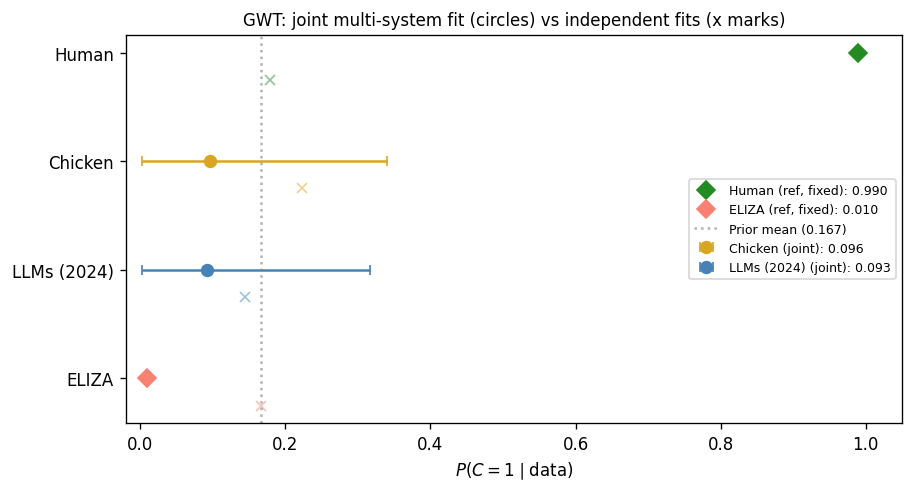

In [ ]:
# Forest plot: joint fit vs independent fits (from notebook 10 if available)
PRIOR_MEAN = 1 / 6

# Independent fit results (from notebook 10, hardcoded for comparison)
indep = {
    "Human": 0.179,
    "Chicken": 0.223,
    "2024 Leading Chat LLMs": 0.144,
    "ELIZA": 0.166,
}

fig, ax = plt.subplots(figsize=(7.5, 4.0))
y = 0
yticks = []
ylabels = []
colours = {
    "Human": "forestgreen",
    "Chicken": "goldenrod",
    "2024 Leading Chat LLMs": "steelblue",
    "ELIZA": "salmon",
}
display = {"2024 Leading Chat LLMs": "LLMs (2024)"}

for sys_name in [s for s, _ in SYSTEM_CONFIGS]:
    r = sys_results[sys_name]
    lbl = display.get(sys_name, sys_name)
    col = colours[sys_name]

    if not r["fixed"]:
        # Joint fit (target systems with posterior)
        ax.errorbar(
            [r["mean"]],
            [y],
            xerr=[[r["mean"] - r["ci_low"]], [r["ci_high"] - r["mean"]]],
            fmt="o",
            color=col,
            capsize=3,
            markersize=7,
            label=f"{lbl} (joint): {r['mean']:.3f}",
        )
    else:
        # Reference systems (fixed C)
        ax.plot(
            [r["mean"]],
            [y],
            "D",
            color=col,
            markersize=8,
            label=f"{lbl} (ref, fixed): {r['mean']:.3f}",
        )

    # Independent fit comparison (smaller, hollow)
    if sys_name in indep:
        ax.plot([indep[sys_name]], [y + 0.25], "x", color=col, markersize=6, alpha=0.5)

    yticks.append(y)
    ylabels.append(lbl)
    y += 1

ax.axvline(
    PRIOR_MEAN,
    color="grey",
    linestyle=":",
    alpha=0.6,
    label=f"Prior mean ({PRIOR_MEAN:.3f})",
)
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels, fontsize=10)
ax.set_xlabel(r"$P(C=1 \mid \text{data})$")
ax.set_xlim(-0.02, 1.05)
ax.invert_yaxis()
ax.legend(fontsize=7.5, loc="center right")
ax.set_title(
    "GWT: joint multi-system fit (circles) vs independent fits (x marks)", fontsize=10
)
plt.show()

In [ ]:
# Observation-layer diagnostics
a_mean = float(post["a"].mean())
kappa_mean = post["kappa"].mean(dim=("chain", "draw")).values
print(f"Shared observation-layer parameters:")
print(f"  a (discrimination): {a_mean:.3f}")
print(f"  kappa (cutpoints):  [{', '.join(f'{v:.3f}' for v in kappa_mean)}]")

n_experts = len(processor.expert_names)
if n_experts > 1 and "b_free" in post:
    b_free_mean = post["b_free"].mean(dim=("chain", "draw")).values
    print(
        f"  b (expert shifts):  [0.000 ({processor.anchor_expert}), "
        + ", ".join(f"{v:.3f}" for v in b_free_mean)
        + "]"
    )
    print(f"  experts: {processor.expert_names}")

# Convergence summary
summary = az.summary(idata, var_names=["a", "kappa"], kind="diagnostics")
n_div = int(idata.sample_stats["diverging"].values.sum())
print(f"\nConvergence:")
print(f"  divergences: {n_div}")
print(f"  max R-hat (a, kappa): {float(summary['r_hat'].max()):.3f}")
print(f"  min ESS (a, kappa):   {float(summary['ess_bulk'].min()):.0f}")

Shared observation-layer parameters:
  a (discrimination): 2.749
  kappa (cutpoints):  [-0.054, 0.252, 0.525, 0.997, 1.674, 2.493]
  b (expert shifts):  [0.000 (Derek Shiller), 0.396, 0.589, 1.751, 0.633, 1.132]
  experts: ['Derek Shiller', 'Andreas Mogensen', 'Felix Binder', 'Hayley chickens', 'Luhan Mikaelson', 'Rachael Miller']

Convergence:
  divergences: 0
  max R-hat (a, kappa): 1.000
  min ESS (a, kappa):   4035


## Interpretation

**Key questions:**
1. Does the ordering come out Human >> Chicken > LLMs > ELIZA?
2. How does the shared `a` compare to the independent LLM-only estimate (~1.45)?
3. How much did the LLM posterior shift from the independent fit (0.144)?
4. Are Chicken and LLMs meaningfully separated, or still clustered?